In [1]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
from sascorer import compute_sa_score

def calculate(mol):
    mol_weight = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)
    qed = QED.qed(mol)
    tpsa = Descriptors.TPSA(mol)
    sa = compute_sa_score(mol)
    rot = Descriptors.NumRotatableBonds(mol)
    return mol_weight, logp, h_donors, h_acceptors, qed, tpsa, sa, rot

data = pd.read_csv("./datasets/finetuning/EP4/csv4screen.csv")

selected_smiles = []

for smiles in data["canonical_smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    mol_weight, logp, h_donors, h_acceptors, qed, tpsa, sa, rot= calculate(mol)

    # 根据条件进行筛选
    if 450 <= mol_weight <= 600 and 5 <= logp <= 8 and 0 <= h_donors <= 5 and 0 <= h_acceptors <= 10 and qed > 0.25 \
       and tpsa <= 100 and sa < 0.8 and rot < 12:
        selected_smiles.append(smiles)

selected_df = data[data["canonical_smiles"].isin(selected_smiles)]


selected_df

,Unnamed: 0,smiles,scaffold,decorations,canonical_smiles,count,generator_SMILES_scaffold
7,17,C=C(NC(=O)c1c(Cc2ccc(Cl)c(Cl)c2)sc2c1CCOC2)c1c...,[*:0]Cc1sc2c(c1C(=O)N[*:1])CCOC2,"{0: '[*]c1ccc(Cl)c(Cl)c1', 1: '[*]C(=C)c1ccc(C...",C=C(NC(=O)c1c(Cc2ccc(Cl)c(Cl)c2)sc2c1CCOC2)c1c...,1,C=C(NC(=O)c1c(Cc2ccccc2)sc2c1CCOC2)c1ccccc1
8,18,C=C(NC(=O)c1c(Cc2ccccc2OC(F)F)sc2c1CCOC2)c1ccc...,[*:0]c1sc2c(c1[*:1])CCOC2,"{0: '[*]Cc1ccccc1OC(F)F', 1: '[*]C(=O)NC(=C)c1...",C=C(NC(=O)c1c(Cc2ccccc2OC(F)F)sc2c1CCOC2)c1ccc...,1,C=C(NC(=O)c1c(Cc2ccccc2)sc2c1CCOC2)c1ccccc1
14,37,CC#COc1cccc(CCc2sc3c(c2C(=O)NC(C)c2ccc(C(=O)OC...,[*:0]CCc1sc2c(c1C(=O)[*:1])CCOC2,"{0: '[*]c1cccc(OC#CC)c1', 1: '[*]NC(C)c1ccc(C(...",CC#COc1cccc(CCc2sc3c(c2C(=O)NC(C)c2ccc(C(=O)OC...,1,O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCOC2
15,39,CC#Cc1ccc(C)c(Cc2sc3c(c2C(=O)NC(C)C2CCCC(C(=O)...,[*:0]C(=O)c1c([*:1])sc2c1CCOC2,"{0: '[*]NC(C)C1CCCC(C(=O)O)C1', 1: '[*]Cc1cc(C...",CC#Cc1ccc(C)c(Cc2sc3c(c2C(=O)NC(C)C2CCCC(C(=O)...,1,O=C(NCC1CCCCC1)c1c(Cc2ccccc2)sc2c1CCOC2
22,135,CC(=O)Oc1ccc(C(C)NC(=O)c2c(Cc3ccc(CC(F)(F)F)cc...,[*:0]C(=O)c1c([*:1])sc2c1CCOC2,"{0: '[*]NC(C)c1ccc(OC(C)=O)cc1', 1: '[*]Cc1ccc...",CC(=O)Oc1ccc(C(C)NC(=O)c2c(Cc3ccc(CC(F)(F)F)cc...,1,O=C(NCc1ccccc1)c1c(Cc2ccccc2)sc2c1CCOC2
23,136,CC(=O)Oc1ccc(C(C)NC(=O)c2c(NCc3cccc(C(F)(F)F)c...,[*:0]Nc1sc2c(c1C(=O)[*:1])CCOC2,"{0: '[*]Cc1cccc(C(F)(F)F)c1Cl', 1: '[*]NC(C)c1...",CC(=O)Oc1ccc(C(C)NC(=O)c2c(NCc3cccc(C(F)(F)F)c...,1,O=C(NCc1ccccc1)c1c(NCc2ccccc2)sc2c1CCOC2
26,139,CC(=O)Sc1ccc([C@H](C)NC(=O)c2c(CCc3ccc(C)cc3)s...,[*:0]CCc1sc2c(c1C(=O)N[C@@H](C)[*:1])CCCC2,"{0: '[*]c1ccc(C)cc1', 1: '[*]c1ccc(SC(C)=O)cc1'}",CC(=O)Sc1ccc([C@H](C)NC(=O)c2c(CCc3ccc(C)cc3)s...,1,O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCCC2
28,156,CC(=O)c1ccc(C(C)NC(=O)c2c(CCc3ccc(CO)cc3)sc3c2...,[*:0]NC(=O)c1c(CCc2ccc([*:1])cc2)sc2c1CCCC2,"{0: '[*]C(C)c1ccc(C(C)=O)cc1', 1: '[*]CO'}",CC(=O)c1ccc(C(C)NC(=O)c2c(CCc3ccc(CO)cc3)sc3c2...,3,O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCCC2
29,158,CC(=O)c1ccc(C(C)NC(=O)c2c(Cc3ccc(CNC(F)(F)F)cc...,[*:0]C(=O)c1c([*:1])sc2c1CCOC2,"{0: '[*]NC(C)c1ccc(C(C)=O)cc1', 1: '[*]Cc1ccc(...",CC(=O)c1ccc(C(C)NC(=O)c2c(Cc3ccc(CNC(F)(F)F)cc...,1,O=C(NCc1ccccc1)c1c(Cc2ccccc2)sc2c1CCOC2
35,180,CC(=O)c1ccc([C@H](C)NC(=O)c2c(CCc3ccc(F)cc3F)s...,[*:0]CCc1sc2c(c1C(=O)N[C@@H](C)c1ccc(C(=O)[*:1...,"{0: '[*]c1ccc(F)cc1F', 1: '[*]C'}",CC(=O)c1ccc([C@H](C)NC(=O)c2c(CCc3ccc(F)cc3F)s...,3,O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCOC2


In [2]:
def Calc_AROM(mh):
    m = Chem.RemoveHs(mh)
    ring_info = m.GetRingInfo()
    atoms_in_rings = ring_info.AtomRings()
    num_aromatic_ring = 0
    for ring in atoms_in_rings:
        aromatic_atom_in_ring = 0
        for atom_id in ring:
            atom = m.GetAtomWithIdx(atom_id)
            if atom.GetIsAromatic():
                aromatic_atom_in_ring += 1
        if aromatic_atom_in_ring == len(ring):
            num_aromatic_ring += 1
    return num_aromatic_ring


df_threshold = pd.DataFrame()

patt = Chem.MolFromSmiles("C1=CC=C(C=C1)C(=O)O")

for index, row in selected_df.iterrows():
    Atom = []
    gen_smile = row['canonical_smiles']
    
    mol = Chem.MolFromSmiles(gen_smile)
    hit_ats = mol.GetSubstructMatches(patt)
    
    for atom in mol.GetAtoms(): 
        Atom.append(atom.GetSymbol())
        
    num = Calc_AROM(mol)
        
    if len(hit_ats) > 0 and "Li" not in Atom and num < 4:
        df_threshold = df_threshold.append(selected_df.loc[index])
        
df_threshold

,Unnamed: 0,canonical_smiles,count,decorations,generator_SMILES_scaffold,scaffold,smiles
7,17.0,C=C(NC(=O)c1c(Cc2ccc(Cl)c(Cl)c2)sc2c1CCOC2)c1c...,1.0,"{0: '[*]c1ccc(Cl)c(Cl)c1', 1: '[*]C(=C)c1ccc(C...",C=C(NC(=O)c1c(Cc2ccccc2)sc2c1CCOC2)c1ccccc1,[*:0]Cc1sc2c(c1C(=O)N[*:1])CCOC2,C=C(NC(=O)c1c(Cc2ccc(Cl)c(Cl)c2)sc2c1CCOC2)c1c...
8,18.0,C=C(NC(=O)c1c(Cc2ccccc2OC(F)F)sc2c1CCOC2)c1ccc...,1.0,"{0: '[*]Cc1ccccc1OC(F)F', 1: '[*]C(=O)NC(=C)c1...",C=C(NC(=O)c1c(Cc2ccccc2)sc2c1CCOC2)c1ccccc1,[*:0]c1sc2c(c1[*:1])CCOC2,C=C(NC(=O)c1c(Cc2ccccc2OC(F)F)sc2c1CCOC2)c1ccc...
14,37.0,CC#COc1cccc(CCc2sc3c(c2C(=O)NC(C)c2ccc(C(=O)OC...,1.0,"{0: '[*]c1cccc(OC#CC)c1', 1: '[*]NC(C)c1ccc(C(...",O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCOC2,[*:0]CCc1sc2c(c1C(=O)[*:1])CCOC2,CC#COc1cccc(CCc2sc3c(c2C(=O)NC(C)c2ccc(C(=O)OC...
41,225.0,CC(C)(NC(=O)c1c(CCc2cccc(I)c2)sc2c1CCOC2)c1ccc...,1.0,"{0: '[*]I', 1: '[*]C(=O)NC(C)(C)c1ccc(C(=O)O)c...",O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCOC2,[*:0]c1cccc(CCc2sc3c(c2[*:1])CCOC3)c1,CC(C)(NC(=O)c1c(CCc2cccc(I)c2)sc2c1CCOC2)c1ccc...
43,227.0,CC(C)(NC(=O)c1c(NCc2cc(F)cc(C(F)(F)F)c2)sc2c1C...,2.0,"{0: '[*]Cc1cc(F)cc(C(F)(F)F)c1', 1: '[*]C(=O)N...",O=C(NCc1ccccc1)c1c(NCc2ccccc2)sc2c1CCOC2,[*:0]Nc1sc2c(c1[*:1])CCOC2,CC(C)(NC(=O)c1c(NCc2cc(F)cc(C(F)(F)F)c2)sc2c1C...
46,315.0,CC(Cc1sc2c(c1C(=O)NC(=O)c1ccc(C(=O)O)cc1)CCCC2...,1.0,"{0: '[*]C(C)c1ccc(Cl)cc1', 1: '[*]C(=O)c1ccc(C...",O=C(NC(=O)c1c(CCc2ccccc2)sc2c1CCCC2)c1ccccc1,[*:0]Cc1sc2c(c1C(=O)N[*:1])CCCC2,CC(Cc1sc2c(c1C(=O)NC(=O)c1ccc(C(=O)O)cc1)CCCC2...
49,320.0,CC(Cc1sc2c(c1C(=O)N[C@@H](C)c1ccc(C(=O)O)c(Br)...,1.0,"{0: '[*]C(C)c1cccc(F)c1', 1: '[*]c1ccc(C(=O)O)...",O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCC2,[*:0]Cc1sc2c(c1C(=O)N[C@@H](C)[*:1])CCC2,CC(Cc1sc2c(c1C(=O)N[C@@H](C)c1ccc(C(=O)O)c(Br)...
58,383.0,CC(NC(=O)c1c(C#Cc2cc(F)cc(C(F)F)c2)sc2c1CCC2)c...,119.0,"{0: '[*]c1cc(F)cc(C(F)F)c1', 1: '[*]C(C)c1ccc(...",O=C(NCc1ccccc1)c1c(C#Cc2ccccc2)sc2c1CCC2,[*:0]C#Cc1sc2c(c1C(=O)N[*:1])CCC2,CC(NC(=O)c1c(C#Cc2cc(F)cc(C(F)F)c2)sc2c1CCC2)c...
65,406.0,CC(NC(=O)c1c(CCc2ccc(C(F)Cl)cc2)sc2c1CCOC2)c1c...,54.0,"{0: '[*]C(F)Cl', 1: '[*]C(=O)NC(C)c1ccc(C(=O)O...",O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCOC2,[*:0]c1ccc(CCc2sc3c(c2[*:1])CCOC3)cc1,CC(NC(=O)c1c(CCc2ccc(C(F)Cl)cc2)sc2c1CCOC2)c1c...
66,407.0,CC(NC(=O)c1c(CCc2ccc(C(F)F)cc2)sc2c1CC(C)(C)OC...,1.0,"{0: '[*]c1ccc(C(F)F)cc1', 1: '[*]C(=O)NC(C)c1c...",O=C(NCc1ccccc1)c1c(CCc2ccccc2)sc2c1CCOC2,[*:0]CCc1sc2c(c1[*:1])CC(C)(C)OC2,CC(NC(=O)c1c(CCc2ccc(C(F)F)cc2)sc2c1CC(C)(C)OC...


In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

data = pd.read_csv("./datasets/finetuning/EP4/EP4_Lipinski_Benzoic acid.csv")
smiles_column = 'canonical_smiles'
smiles_data = data[smiles_column]

def generate_ecfp(smiles_list):
    mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]
    fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) for m in mols]
    return np.array(fps)

fps = generate_ecfp(smiles_data)
n_clusters = 100  
clustering = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(fps)

tsne = TSNE(n_components=2, perplexity=30, random_state=2023)
tsne_result = tsne.fit_transform(fps)

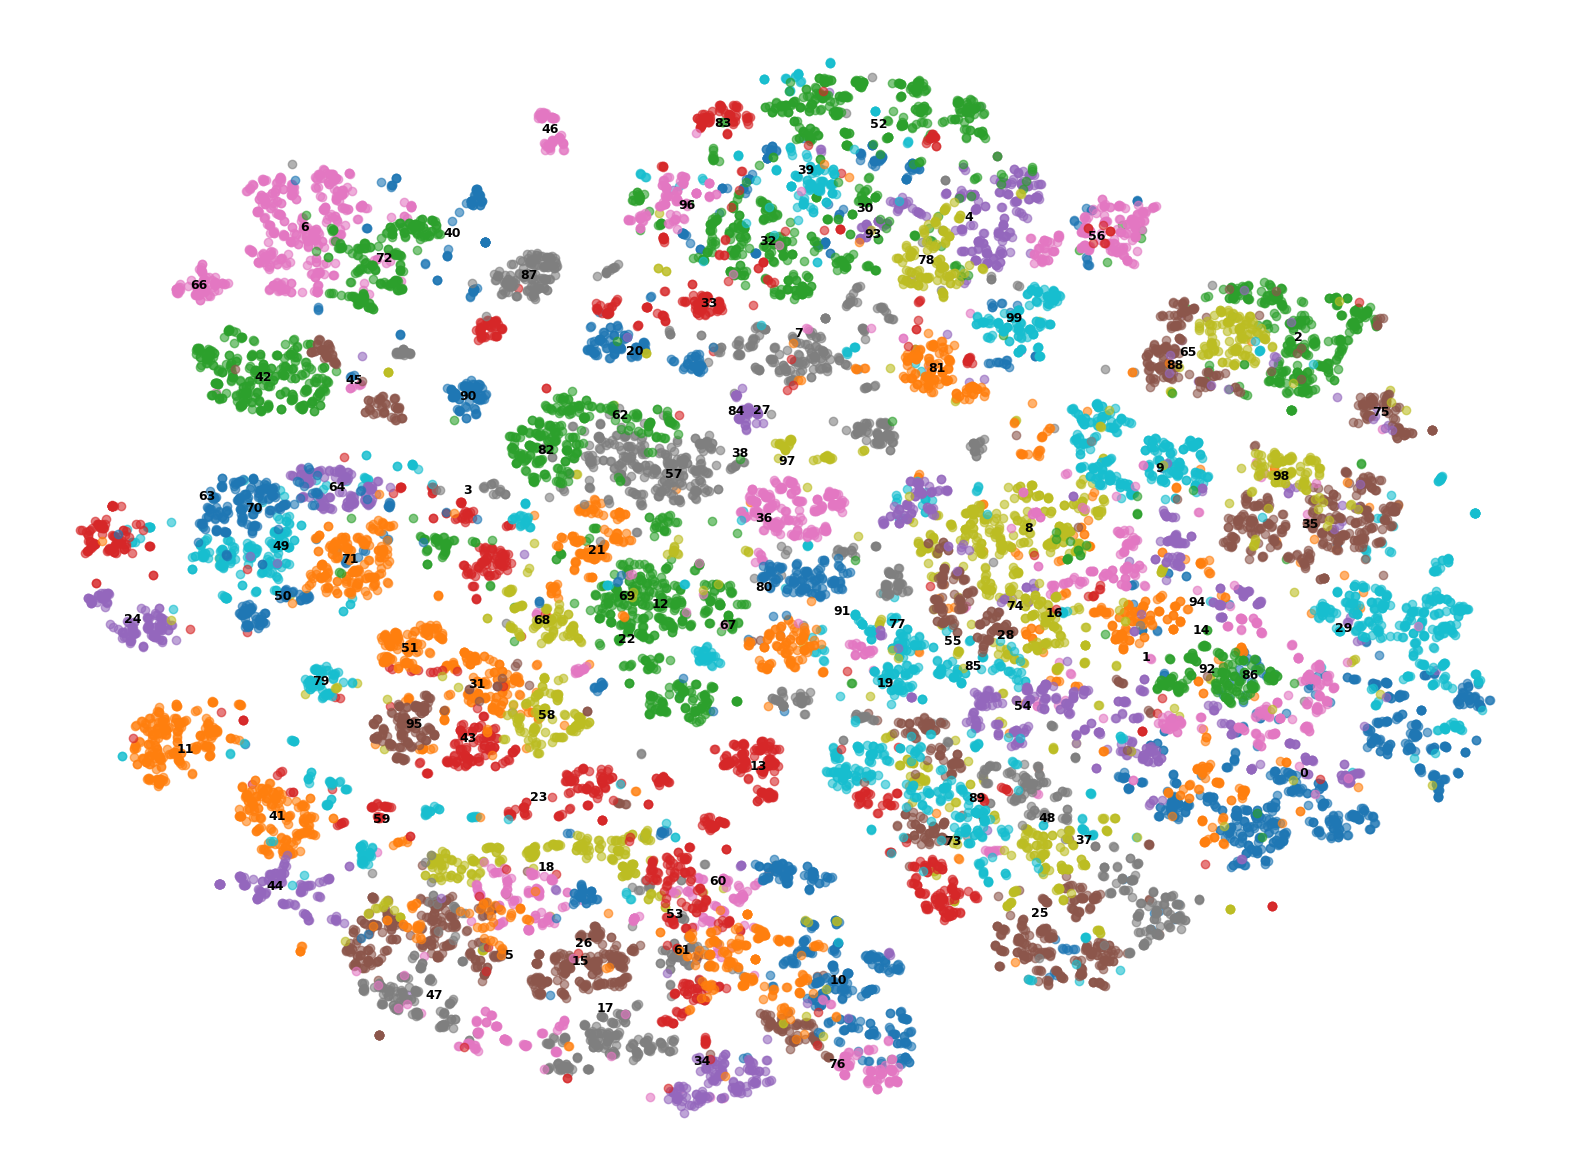

In [6]:
plt.figure(figsize=(20, 15))
for cluster_id in range(n_clusters):
    cluster_samples = tsne_result[clustering == cluster_id]
    cluster_center = np.mean(cluster_samples, axis=0)
    plt.scatter(cluster_samples[:, 0], cluster_samples[:, 1], alpha=0.6, cmap='bwr')
    plt.annotate(f'{cluster_id}', cluster_center, fontsize=9, weight='bold', color='black', ha='center', va='center')


# plt.legend()
plt.axis('off')  # 去掉坐标轴
# plt.title('t-SNE Visualization with Clustering')
plt.savefig('cluster.png', bbox_inches='tight')

plt.show()
